# 06 - Analyse de la vitesse et de la direction

Dans cette étape, nous allons analyser la trajectoire globale de l’objet obtenue précédemment. À partir des positions successives de l’objet, nous allons calculer le déplacement entre deux frames, la distance parcourue, la vitesse et la direction du mouvement.

La trajectoire donne la position de l’objet dans chaque frame. En comparant deux positions successives, nous pouvons estimer le mouvement de l’objet entre ces deux instants.

## 1. Importation des bibliothèques

Nous importons les bibliothèques nécessaires pour charger la trajectoire, calculer les grandeurs du mouvement et tracer les graphes.

In [1]:
import os
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../")

try:
    from src.analysis import compute_displacements, compute_speed, compute_direction
    print("Fonctions importées depuis src.analysis.")
except ImportError:
    compute_displacements = None
    compute_speed = None
    compute_direction = None
    print("Import impossible : des fonctions simples seront définies dans le notebook si nécessaire.")

Fonctions importées depuis src.analysis.


## 2. Chargement de la trajectoire

Nous chargeons le fichier `trajectory.csv` généré dans l’étape précédente. Ce fichier contient les positions de l’objet dans les frames traitées.

In [2]:
trajectory_path = Path("../results/trajectory.csv")
plots_path = Path("../results/plots")
plots_path.mkdir(parents=True, exist_ok=True)

trajectory_df = pd.DataFrame(columns=["frame", "x", "y", "tracked_points"])

print("Chemin du fichier trajectory.csv :", trajectory_path)
print("Le fichier existe :", trajectory_path.exists())

if trajectory_path.exists():
    trajectory_df = pd.read_csv(trajectory_path)
    display(trajectory_df.head())
    print("Nombre total de positions :", len(trajectory_df))

    required_columns = ["frame", "x", "y"]
    for column in required_columns:
        if column in trajectory_df.columns:
            print(f"Colonne {column} disponible.")
        else:
            print(f"Attention : la colonne {column} est absente.")
else:
    print("Le fichier trajectory.csv est introuvable. Il faut exécuter l'étape 05 avant cette analyse.")

Chemin du fichier trajectory.csv : ..\results\trajectory.csv
Le fichier existe : True


,frame,x,y,tracked_points
0,0,639.987488,337.962494,80
1,1,639.347351,337.929504,80
2,2,638.602051,337.767090,80
3,3,637.824585,337.649902,80
4,4,637.050232,337.471985,80


Nombre total de positions : 100
Colonne frame disponible.
Colonne x disponible.
Colonne y disponible.


Le fichier `trajectory.csv` contient les positions globales de l’objet dans les frames traitées. Ces positions seront utilisées pour calculer les grandeurs du mouvement.

## 3. Visualisation rapide de la trajectoire chargée

Nous affichons rapidement la trajectoire dans le plan image pour vérifier que le fichier chargé correspond bien au résultat de l’étape précédente.

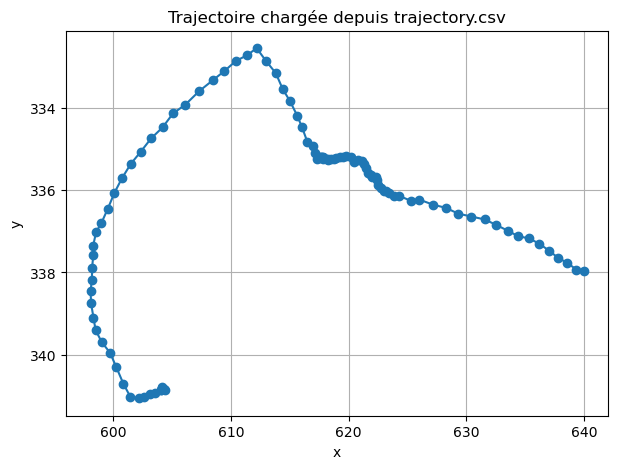

In [3]:
if len(trajectory_df) > 0 and "x" in trajectory_df.columns and "y" in trajectory_df.columns:
    plt.figure(figsize=(7, 5))
    plt.plot(trajectory_df["x"], trajectory_df["y"], marker="o")
    plt.gca().invert_yaxis()
    plt.title("Trajectoire chargée depuis trajectory.csv")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.show()
else:
    print("Impossible d'afficher la trajectoire car les données sont absentes.")

Cette visualisation permet de vérifier que la trajectoire chargée correspond bien à celle extraite dans l’étape précédente.

## 4. Calcul des déplacements dx et dy

Pour deux positions successives :

`dx = x(t+1) - x(t)`  
`dy = y(t+1) - y(t)`

`dx` indique le déplacement horizontal.  
`dy` indique le déplacement vertical.

In [4]:
analysis_df = trajectory_df.copy()

if len(analysis_df) > 0 and "x" in analysis_df.columns and "y" in analysis_df.columns:
    analysis_df["dx"] = analysis_df["x"].diff().fillna(0)
    analysis_df["dy"] = analysis_df["y"].diff().fillna(0)
    display(analysis_df[["frame", "x", "y", "dx", "dy"]].head(10))
else:
    analysis_df["dx"] = []
    analysis_df["dy"] = []
    print("Impossible de calculer dx et dy car la trajectoire est vide ou incomplète.")

,frame,x,y,dx,dy
0,0,639.987488,337.962494,0.000000,0.000000
1,1,639.347351,337.929504,-0.640137,-0.032990
2,2,638.602051,337.767090,-0.745300,-0.162415
3,3,637.824585,337.649902,-0.777466,-0.117188
4,4,637.050232,337.471985,-0.774353,-0.177917
5,5,636.186646,337.296692,-0.863586,-0.175293
6,6,635.331055,337.171875,-0.855591,-0.124817
7,7,634.407593,337.117493,-0.923462,-0.054382
8,8,633.524414,336.983856,-0.883179,-0.133636
9,9,632.541199,336.841675,-0.983215,-0.142181


Les valeurs `dx` et `dy` indiquent comment la position de l’objet change entre deux frames successives.

## 5. Calcul de la distance parcourue entre frames

Nous calculons maintenant la distance entre deux positions successives avec la formule :

`distance = sqrt(dx² + dy²)`

In [5]:
if len(analysis_df) > 0:
    analysis_df["distance"] = np.sqrt(analysis_df["dx"] ** 2 + analysis_df["dy"] ** 2)

    print("Distance moyenne :", analysis_df["distance"].mean())
    print("Distance minimale :", analysis_df["distance"].min())
    print("Distance maximale :", analysis_df["distance"].max())
    print("Distance totale parcourue :", analysis_df["distance"].sum())
else:
    analysis_df["distance"] = []
    print("Impossible de calculer la distance car la trajectoire est vide.")

Distance moyenne : 0.5257668292175508
Distance minimale : 0.0
Distance maximale : 1.2087081106683153
Distance totale parcourue : 52.57668292175508


La distance représente l’amplitude du déplacement de l’objet entre deux frames. Une distance élevée signifie que l’objet s’est déplacé plus rapidement ou que le suivi a varié davantage.

## 6. Calcul de la vitesse

Si nous ne connaissons pas exactement le FPS, nous pouvons analyser la vitesse en pixels par frame.

`vitesse = distance / Δt`

Si `Δt = 1 frame`, alors :

`vitesse = distance en pixels/frame`

Comme nous travaillons dans le plan image, la vitesse est exprimée en pixels/frame ou pixels/seconde, et non en mètres/seconde.

In [6]:
fps = 30

if len(analysis_df) > 0:
    analysis_df["speed_px_per_frame"] = analysis_df["distance"]
    analysis_df["speed_px_per_second"] = analysis_df["distance"] * fps

    print("Vitesse moyenne en pixels/frame :", analysis_df["speed_px_per_frame"].mean())
    print("Vitesse maximale en pixels/frame :", analysis_df["speed_px_per_frame"].max())
    print("Vitesse moyenne en pixels/seconde :", analysis_df["speed_px_per_second"].mean())
    print("Vitesse maximale en pixels/seconde :", analysis_df["speed_px_per_second"].max())
else:
    analysis_df["speed_px_per_frame"] = []
    analysis_df["speed_px_per_second"] = []
    print("Impossible de calculer la vitesse car la trajectoire est vide.")

Vitesse moyenne en pixels/frame : 0.5257668292175508
Vitesse maximale en pixels/frame : 1.2087081106683153
Vitesse moyenne en pixels/seconde : 15.773004876526524
Vitesse maximale en pixels/seconde : 36.26124332004946


La vitesse calculée décrit le mouvement apparent de l’objet dans l’image. Elle ne correspond pas directement à la vitesse réelle de la voiture, car nous n’avons pas fait de calibration de caméra.

## 7. Calcul de la direction du mouvement

Nous calculons la direction avec la formule :

`direction = atan2(dy, dx)`

Cette direction est exprimée en degrés.

In [7]:
if len(analysis_df) > 0:
    direction_rad = np.arctan2(analysis_df["dy"], analysis_df["dx"])
    analysis_df["direction_deg"] = np.degrees(direction_rad)
    display(analysis_df[["frame", "dx", "dy", "direction_deg"]].head(10))
else:
    analysis_df["direction_deg"] = []
    print("Impossible de calculer la direction car la trajectoire est vide.")

,frame,dx,dy,direction_deg
0,0,0.000000,0.000000,0.000000
1,1,-0.640137,-0.032990,-177.049867
2,2,-0.745300,-0.162415,-167.706399
3,3,-0.777466,-0.117188,-171.428328
4,4,-0.774353,-0.177917,-167.060147
5,5,-0.863586,-0.175293,-168.525848
6,6,-0.855591,-0.124817,-171.700020
7,7,-0.923462,-0.054382,-176.629766
8,8,-0.883179,-0.133636,-171.395671
9,9,-0.983215,-0.142181,-171.771578


La direction indique l’orientation du déplacement dans le plan image. Une direction proche de 0° signifie un déplacement vers la droite. Une direction proche de 90° indique un déplacement vers le bas dans le repère image.

## 8. Graphe de la vitesse au cours du temps

Nous traçons la vitesse apparente de l’objet en fonction du numéro de frame.

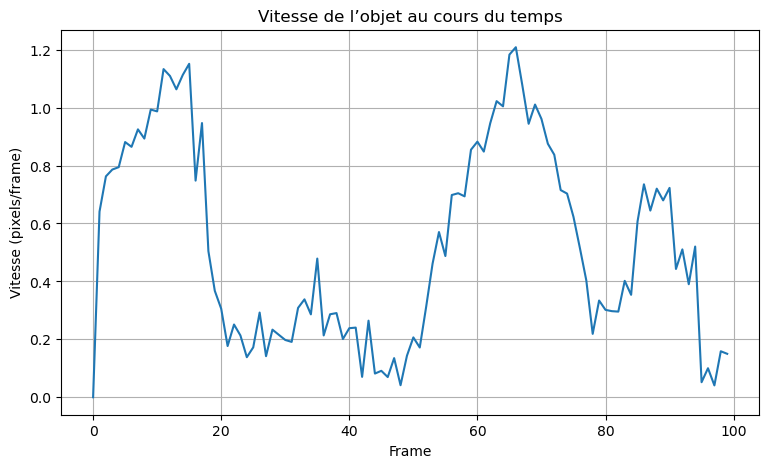

Graphe sauvegardé dans : ..\results\plots\speed_over_time.png


In [8]:
speed_plot_path = plots_path / "speed_over_time.png"

if len(analysis_df) > 0:
    plt.figure(figsize=(9, 5))
    plt.plot(analysis_df["frame"], analysis_df["speed_px_per_frame"])
    plt.title("Vitesse de l’objet au cours du temps")
    plt.xlabel("Frame")
    plt.ylabel("Vitesse (pixels/frame)")
    plt.grid(True)
    plt.savefig(speed_plot_path, bbox_inches="tight")
    plt.show()

    print("Graphe sauvegardé dans :", speed_plot_path)
else:
    print("Impossible de tracer la vitesse car la trajectoire est vide.")

Ce graphe montre comment la vitesse apparente de l’objet évolue au cours de la séquence. Des pics peuvent correspondre à des changements rapides de position ou à de petites instabilités du suivi.

## 9. Graphe de la direction au cours du temps

Nous traçons maintenant l’orientation du mouvement en fonction du numéro de frame.

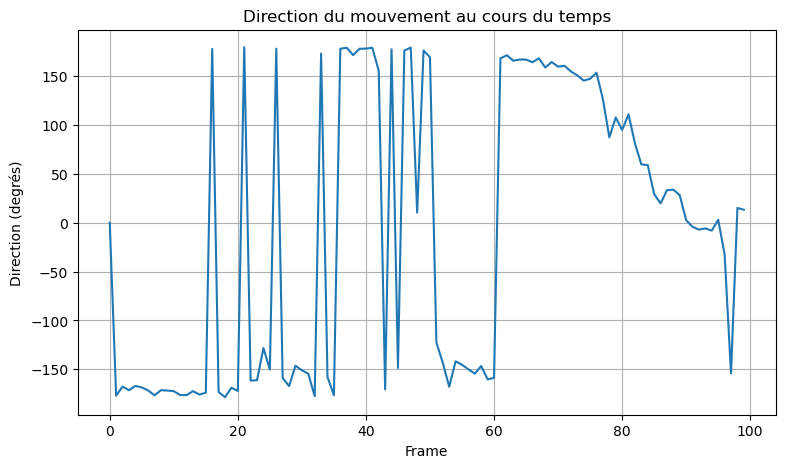

Graphe sauvegardé dans : ..\results\plots\direction_over_time.png


In [9]:
direction_plot_path = plots_path / "direction_over_time.png"

if len(analysis_df) > 0:
    plt.figure(figsize=(9, 5))
    plt.plot(analysis_df["frame"], analysis_df["direction_deg"])
    plt.title("Direction du mouvement au cours du temps")
    plt.xlabel("Frame")
    plt.ylabel("Direction (degrés)")
    plt.grid(True)
    plt.savefig(direction_plot_path, bbox_inches="tight")
    plt.show()

    print("Graphe sauvegardé dans :", direction_plot_path)
else:
    print("Impossible de tracer la direction car la trajectoire est vide.")

Ce graphe montre l’évolution de l’orientation du mouvement. Si la direction reste globalement stable, cela signifie que l’objet suit une trajectoire régulière.

## 10. Graphe des déplacements dx et dy

Nous comparons le déplacement horizontal `dx` et le déplacement vertical `dy` dans une même figure.

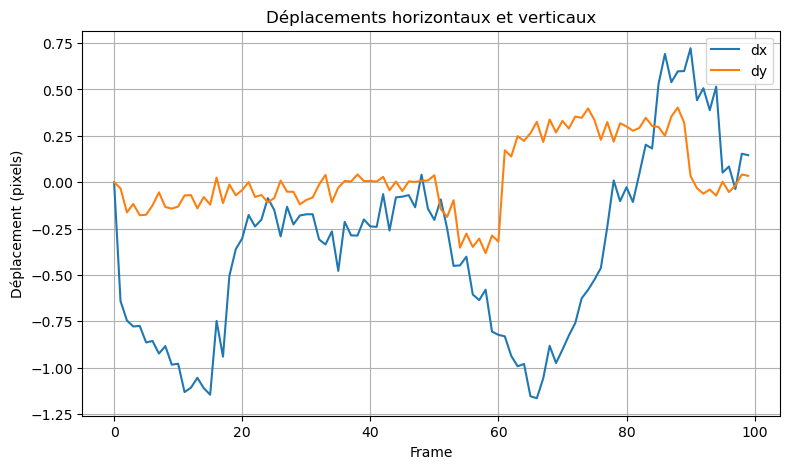

Graphe sauvegardé dans : ..\results\plots\displacements_dx_dy.png


In [10]:
displacements_plot_path = plots_path / "displacements_dx_dy.png"

if len(analysis_df) > 0:
    plt.figure(figsize=(9, 5))
    plt.plot(analysis_df["frame"], analysis_df["dx"], label="dx")
    plt.plot(analysis_df["frame"], analysis_df["dy"], label="dy")
    plt.title("Déplacements horizontaux et verticaux")
    plt.xlabel("Frame")
    plt.ylabel("Déplacement (pixels)")
    plt.legend()
    plt.grid(True)
    plt.savefig(displacements_plot_path, bbox_inches="tight")
    plt.show()

    print("Graphe sauvegardé dans :", displacements_plot_path)
else:
    print("Impossible de tracer dx et dy car la trajectoire est vide.")

Ce graphe permet de comparer le déplacement horizontal et vertical. Dans notre cas, si `dx` est généralement positif, cela signifie que l’objet se déplace principalement vers la droite.

## 11. Résumé numérique du mouvement

Nous affichons maintenant un résumé numérique simple du mouvement de l’objet.

In [11]:
if len(analysis_df) > 0:
    direction_without_first = analysis_df["direction_deg"].iloc[1:]

    number_of_frames = len(analysis_df)
    total_distance = analysis_df["distance"].sum()
    mean_speed = analysis_df["speed_px_per_frame"].mean()
    max_speed = analysis_df["speed_px_per_frame"].max()
    mean_direction = direction_without_first.mean()
    total_dx = analysis_df["dx"].sum()
    total_dy = analysis_df["dy"].sum()

    print("Résumé du mouvement")
    print("-")
    print("Nombre de frames analysées :", number_of_frames)
    print("Distance totale parcourue en pixels :", total_distance)
    print("Vitesse moyenne en pixels/frame :", mean_speed)
    print("Vitesse maximale en pixels/frame :", max_speed)
    print("Direction moyenne en degrés :", mean_direction)
    print("Déplacement horizontal total :", total_dx)
    print("Déplacement vertical total :", total_dy)

    if total_dx > 0:
        print("Interprétation : l’objet se déplace globalement vers la droite.")
    elif total_dx < 0:
        print("Interprétation : l’objet se déplace globalement vers la gauche.")
    else:
        print("Interprétation : l’objet n’a pas de déplacement horizontal global marqué.")

    if total_dy > 0:
        print("Interprétation : l’objet descend globalement dans l’image.")
    elif total_dy < 0:
        print("Interprétation : l’objet monte globalement dans l’image.")
    else:
        print("Interprétation : l’objet n’a pas de déplacement vertical global marqué.")
else:
    print("Impossible de produire le résumé car la trajectoire est vide.")

Résumé du mouvement
-
Nombre de frames analysées : 100
Distance totale parcourue en pixels : 52.57668292175508
Vitesse moyenne en pixels/frame : 0.5257668292175508
Vitesse maximale en pixels/frame : 1.2087081106683153
Direction moyenne en degrés : -9.090631518917528
Déplacement horizontal total : -35.55255126953125
Déplacement vertical total : 2.901275634765625
Interprétation : l’objet se déplace globalement vers la gauche.
Interprétation : l’objet descend globalement dans l’image.


Ce résumé donne une description globale du mouvement de l’objet dans la séquence.

## 12. Sauvegarde des résultats d’analyse

Nous sauvegardons le DataFrame enrichi avec les déplacements, la distance, la vitesse et la direction.

In [12]:
motion_analysis_path = Path("../results/motion_analysis.csv")

if len(analysis_df) > 0:
    analysis_df.to_csv(motion_analysis_path, index=False)
    display(analysis_df.head())
    print("Résultats d'analyse sauvegardés dans :", motion_analysis_path)
else:
    print("Aucun résultat d'analyse à sauvegarder.")

,frame,x,y,tracked_points,dx,dy,distance,speed_px_per_frame,speed_px_per_second,direction_deg
0,0,639.987488,337.962494,80,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,639.347351,337.929504,80,-0.640137,-0.032990,0.640986,0.640986,19.229586,-177.049867
2,2,638.602051,337.767090,80,-0.745300,-0.162415,0.762792,0.762792,22.883748,-167.706399
3,3,637.824585,337.649902,80,-0.777466,-0.117188,0.786248,0.786248,23.587442,-171.428328
4,4,637.050232,337.471985,80,-0.774353,-0.177917,0.794530,0.794530,23.835887,-167.060147


Résultats d'analyse sauvegardés dans : ..\results\motion_analysis.csv


Le fichier `motion_analysis.csv` regroupe la trajectoire et les grandeurs calculées. Il pourra être utilisé dans la dernière étape pour générer les visualisations finales.

## 13. Création de fonctions simples d’analyse

Nous regroupons les calculs principaux dans des fonctions simples pour rendre le travail plus réutilisable.

In [13]:
def compute_displacements(trajectory_df):
    """
    Calcule dx et dy entre positions successives.
    """
    result = trajectory_df.copy()
    result["dx"] = result["x"].diff().fillna(0)
    result["dy"] = result["y"].diff().fillna(0)
    return result


def compute_speed(analysis_df, fps=30):
    """
    Calcule la vitesse en pixels/frame et pixels/seconde.
    """
    result = analysis_df.copy()
    result["distance"] = np.sqrt(result["dx"] ** 2 + result["dy"] ** 2)
    result["speed_px_per_frame"] = result["distance"]
    result["speed_px_per_second"] = result["distance"] * fps
    return result


def compute_direction(analysis_df):
    """
    Calcule la direction du mouvement en degrés.
    """
    result = analysis_df.copy()
    direction_rad = np.arctan2(result["dy"], result["dx"])
    result["direction_deg"] = np.degrees(direction_rad)
    return result

Nous testons brièvement ces fonctions sur la trajectoire chargée.

In [14]:
if len(trajectory_df) > 0:
    test_df = compute_displacements(trajectory_df)
    test_df = compute_speed(test_df, fps=30)
    test_df = compute_direction(test_df)
    display(test_df.head())
else:
    print("Impossible de tester les fonctions car la trajectoire est vide.")

,frame,x,y,tracked_points,dx,dy,distance,speed_px_per_frame,speed_px_per_second,direction_deg
0,0,639.987488,337.962494,80,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,639.347351,337.929504,80,-0.640137,-0.032990,0.640986,0.640986,19.229586,-177.049867
2,2,638.602051,337.767090,80,-0.745300,-0.162415,0.762792,0.762792,22.883748,-167.706399
3,3,637.824585,337.649902,80,-0.777466,-0.117188,0.786248,0.786248,23.587442,-171.428328
4,4,637.050232,337.471985,80,-0.774353,-0.177917,0.794530,0.794530,23.835887,-167.060147


## 14. Conclusion de l’analyse vitesse-direction

Dans cette étape, nous avons analysé la trajectoire extraite dans l’étape précédente. Nous avons calculé les déplacements horizontaux et verticaux, la distance parcourue, la vitesse apparente en pixels/frame et la direction du mouvement. Ces résultats permettent de décrire quantitativement le mouvement de l’objet dans la séquence. Dans la dernière étape, nous regrouperons les visualisations finales pour présenter clairement les résultats du projet.

Nous nous arrêtons ici : l’étape 07 sera préparée séparément.